ModuleNotFoundError: No module named 'pandas'

In [2]:
!pip install pandas


  Using cached pandas-3.0.5-cp311-cp311-macosx_11_0_arm64.whl.metadata (79 kB)
Using cached pandas-3.0.5-cp311-cp311-macosx_11_0_arm64.whl (10.0 MB)


In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout

In [4]:
metadata = pd.read_csv("UrbanSound8K/metadata/UrbanSound8K.csv")

metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [5]:
DATA_PATH = "UrbanSound8K/audio"

features = []
labels = []

for index, row in metadata.iterrows():

    file_path = os.path.join(
        DATA_PATH,
        f"fold{row['fold']}",
        row["slice_file_name"]
    )

    try:
        y, sr = librosa.load(file_path, sr=22050)

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=128
        )

        mel_db = librosa.power_to_db(mel)

        # Fixed size
        if mel_db.shape[1] < 128:
            pad = 128 - mel_db.shape[1]
            mel_db = np.pad(
                mel_db,
                ((0,0),(0,pad))
            )
        else:
            mel_db = mel_db[:, :128]

        features.append(mel_db)
        labels.append(row["class"])

    except:
        pass

print("Samples:", len(features))

/opt/anaconda3/envs/dtln/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/dtln/lib/python3.11/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
/opt/anaconda3/envs/dtln/lib/python3.11/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/opt/anaconda3/envs/dtln/lib/python3.11/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(


Samples: 8732


In [6]:
X = np.array(features)
y = np.array(labels)

X = X.reshape(
    X.shape[0],
    X.shape[1],
    X.shape[2],
    1
)

encoder = LabelEncoder()

y = encoder.fit_transform(y)

y = to_categorical(y)

print(X.shape)
print(y.shape)

(8732, 128, 128, 1)
(8732, 10)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(128,128,1)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation="relu"))

model.add(Dropout(0.3))

model.add(Dense(10, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 57600)             0         
                                                                 
 dense (Dense)               (None, 128)               7

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
219/219 [==============================] - 20s 91ms/step - loss: 3.9460 - accuracy: 0.4093 - val_loss: 1.1182 - val_accuracy: 0.6577
Epoch 2/20
219/219 [==============================] - 20s 92ms/step - loss: 1.0495 - accuracy: 0.6555 - val_loss: 0.8945 - val_accuracy: 0.7321
Epoch 3/20
219/219 [==============================] - 20s 92ms/step - loss: 0.7147 - accuracy: 0.7658 - val_loss: 0.7337 - val_accuracy: 0.7722
Epoch 4/20
219/219 [==============================] - 21s 94ms/step - loss: 0.5056 - accuracy: 0.8344 - val_loss: 0.7231 - val_accuracy: 0.7911
Epoch 5/20
219/219 [==============================] - 21s 94ms/step - loss: 0.3719 - accuracy: 0.8796 - val_loss: 0.7372 - val_accuracy: 0.8002
Epoch 6/20
219/219 [==============================] - 20s 92ms/step - loss: 0.2918 - accuracy: 0.9054 - val_loss: 0.7448 - val_accuracy: 0.8122
Epoch 7/20
219/219 [==============================] - 20s 92ms/step - loss: 0.2341 - accuracy: 0.9260 - val_loss: 0.7036 - val_accuracy:

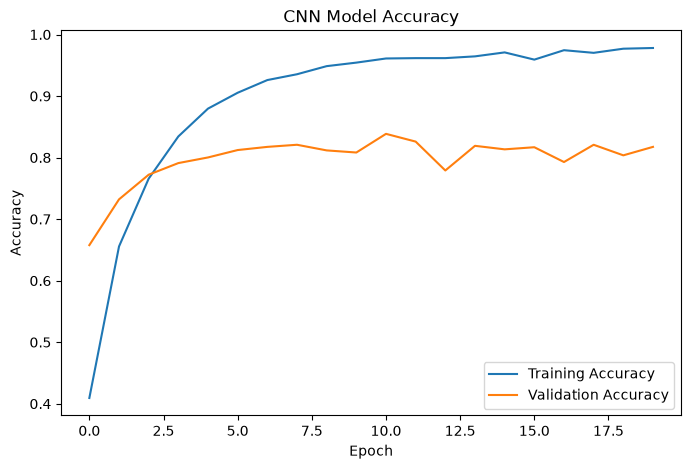

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

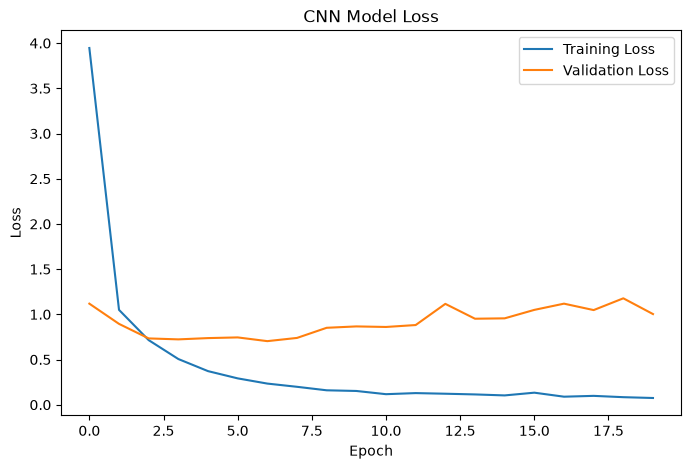

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

55/55 [==============================] - 1s 24ms/step - loss: 1.0031 - accuracy: 0.8174
Test Loss : 1.0030584335327148
Test Accuracy : 0.8174012303352356


In [13]:
predictions = model.predict(X_test)

predicted_class = np.argmax(predictions, axis=1)
actual_class = np.argmax(y_test, axis=1)

for i in range(10):
    print(
        "Actual:",
        encoder.inverse_transform([actual_class[i]])[0],
        "| Predicted:",
        encoder.inverse_transform([predicted_class[i]])[0]
    )

55/55 [==============================] - 1s 25ms/step
Actual: siren | Predicted: jackhammer
Actual: street_music | Predicted: street_music
Actual: drilling | Predicted: children_playing
Actual: siren | Predicted: siren
Actual: dog_bark | Predicted: dog_bark
Actual: jackhammer | Predicted: jackhammer
Actual: children_playing | Predicted: children_playing
Actual: children_playing | Predicted: children_playing
Actual: drilling | Predicted: jackhammer
Actual: dog_bark | Predicted: dog_bark


# Observations

- The CNN model successfully classified most environmental sound samples from the UrbanSound8K dataset.
- The model achieved an overall test accuracy of 81.74%.
- Sounds such as dog bark, jackhammer, street music, and children playing were classified correctly.
- A few sounds such as siren and drilling were misclassified. This is likely because some environmental sounds have similar acoustic characteristics, making them harder to distinguish.
- Overall, the CNN demonstrated good performance in recognizing environmental sound events.